# SW-DFL

## Small-World Adaptive Rewiring Decentralised Federated Learning

---

## 1  Problem Setup
$N$ nodes hold private datasets $\mathcal{D}_i$.  DFL objective:
$$\min_{\mathbf{w}}\;F(\mathbf{w})=\frac{1}{N}\sum_{i=1}^N f_i(w_i,\mathcal{D}_i)\quad\text{s.t.}\quad w_i\xrightarrow{t\to\infty}w^*\;\forall i.$$
Dynamic communication graph $G^t=(\mathcal{V},\mathcal{E}^t)$ with $|\mathcal{V}|=N$; $\mathcal{E}^t$ evolves by our rewiring rules, preserving small-world properties.

---

## 2  Small-World Network Topology

The initial topology is a **Watts–Strogatz small-world graph** $G(N, k, p)$:
- $k$: each node connected to $k$ nearest neighbours in a ring lattice
- $p$: probability of rewiring each edge to introduce long-range shortcuts

**Key properties enabling fast communication:**
- **Low average path length** $L \sim \mathcal{O}(\log N)$: information reaches any node in few hops
- **High clustering coefficient** $C \gg C_{\text{random}}$: local neighbourhood redundancy provides robustness

---

## 3  Rewiring Algorithm

### 3.1  Chordal Grassmannian Subspace Divergence

Each layer $\ell$ of model $i$ defines a weight matrix $W_i^\ell \in \mathbb{R}^{n \times m}$.  Via compact SVD $W_i^\ell = U_i^\ell \Sigma_i^\ell (V_i^\ell)^T$, the top-$r$ left singular vectors $U_i^{\ell,r} \in \mathbb{R}^{n \times r}$ span the dominant $r$-dimensional subspace on the **Grassmann manifold** $\mathcal{G}(r,n)$.

**Definition 1.** The *chordal Grassmannian distance* between subspaces $\mathcal{U}_i^\ell$ and $\mathcal{U}_j^\ell$ (Veronese embedding into Frobenius space):
$$d_{\mathcal{G}}^{\mathrm{chord}}(i,j,\ell)
  = \sqrt{1 - \frac{\bigl\|(U_i^{\ell,r})^T\,U_j^{\ell,r}\bigr\|_F^2}{r}}
  \;\in\;[0,\,1].$$

- $d=0$: $\mathcal{U}_i^\ell = \mathcal{U}_j^\ell$ (identical subspaces, redundant edge)
- $d=1$: $\mathcal{U}_i^\ell \perp \mathcal{U}_j^\ell$ (maximally diverse, informative edge)

**Why the cross-Gram norm:** $\|(U_i^{\ell,r})^T U_j^{\ell,r}\|_F^2 = \sum_{k=1}^r \cos^2\theta_k^\ell$, where $\theta_k^\ell$ are the principal angles between the two subspaces.  The chordal distance equals $\sqrt{\sum_k \sin^2\theta_k^\ell / r}$ — a numerically exact, arccos-free measure of subspace misalignment.

**Definition 2.** The *Grassmannian subspace divergence* between models $i$ and $j$ at round $t$, spectral-energy-weighted across all layers:
$$\mathcal{D}_{ij}^t
  = \frac{\displaystyle\sum_\ell \lambda_\ell \cdot d_{\mathcal{G}}^{\mathrm{chord}}(i,j,\ell)}{\displaystyle\sum_\ell \lambda_\ell}
  \;\in\;[0,\,1],
  \qquad
  \lambda_\ell = \|\Sigma_i^{\ell,r}\|_F^2 + \|\Sigma_j^{\ell,r}\|_F^2.$$

### 3.2  Subspace Redundancy Removal
Remove edge $(i,j)\in\mathcal{E}^t$ when subspaces are too aligned:
$$\mathcal{D}_{ij}^t < \tau,\qquad\tau\in(0,1).$$

### 3.3  Small-World Preferential Rewiring
After disconnecting from $j$, node $i$ reconnects by maximising a **shortcut score** balancing subspace diversity with graph distance, preserving the small-world low-diameter property:
$$k^* = \operatornamewithlimits{arg\,max}_{k\notin\mathcal{N}_i^t\cup\{i\}}\;\mathcal{D}_{ik}^t \cdot \log\!\bigl(1 + d_G(i,k)\bigr)$$

### 3.4  Spectral Connectivity Maintenance
After rewiring, check $\lambda_2(G^{t+1})$ (Fiedler value / algebraic connectivity).
If $\lambda_2 < \lambda_{2,\min}$, greedily add the farthest-apart node pair until $\lambda_2\ge\lambda_{2,\min}$.

---

## 4  Confidence-Weighted Aggregation

**Definition 3.** For node $i$ with neighbours $\mathcal{N}_i^t$ and peer accuracies $q_j^t$:
$$w_i^{t+1}=\sum_{j\in\{i\}\cup\mathcal{N}_i^t}\alpha_{ij}^t\,w_j^t,\qquad\alpha_{ij}^t=\frac{\exp(q_j^t/T)}{\displaystyle\sum_{k\in\{i\}\cup\mathcal{N}_i^t}\exp(q_k^t/T)}$$

Model weights are communicated at **full precision** — no quantisation applied.


In [ ]:
import torch
import torch.nn as neural_network
import torch.optim as optimization_module
import torchvision
import torchvision.transforms as data_transforms
from torch.utils.data import DataLoader, random_split
import networkx as graph_library
import math
import random
import matplotlib.pyplot as plotting_module
import matplotlib.gridspec as grid_specification_module
import pandas
import os
import time
import warnings

warnings.filterwarnings('ignore')
torch.manual_seed(42)
random.seed(42)


In [ ]:
def compute_small_world_metrics(network_graph):
    """Compute average path length and clustering coefficient to quantify communication efficiency."""
    if not graph_library.is_connected(network_graph):
        largest_cc = network_graph.subgraph(
            max(graph_library.connected_components(network_graph), key=len)
        ).copy()
    else:
        largest_cc = network_graph

    avg_path_length = graph_library.average_shortest_path_length(largest_cc)
    clustering_coeff = graph_library.average_clustering(network_graph)

    # Small-world index: ratio of normalised clustering to normalised path length vs. an equivalent random graph
    n_nodes = len(network_graph)
    density = graph_library.density(network_graph)
    random_graph = graph_library.erdos_renyi_graph(n_nodes, density, seed=0)
    random_clustering = graph_library.average_clustering(random_graph) + 1e-9
    if graph_library.is_connected(random_graph):
        random_path = graph_library.average_shortest_path_length(random_graph) + 1e-9
    else:
        random_path = avg_path_length + 1e-9
    small_world_index = (clustering_coeff / random_clustering) / (avg_path_length / random_path)

    return avg_path_length, clustering_coeff, small_world_index


In [ ]:
class DigitClassifier(neural_network.Module):
    def __init__(self):
        super().__init__()
        self.flatten_layer = neural_network.Flatten()
        self.fully_connected_one = neural_network.Linear(28 * 28, 200)
        self.activation_one = neural_network.ReLU()
        self.fully_connected_two = neural_network.Linear(200, 200)
        self.activation_two = neural_network.ReLU()
        self.output_layer = neural_network.Linear(200, 10)

    def forward(self, input_tensor):
        flattened = self.flatten_layer(input_tensor)
        hidden_one = self.activation_one(self.fully_connected_one(flattened))
        hidden_two = self.activation_two(self.fully_connected_two(hidden_one))
        return self.output_layer(hidden_two)


In [ ]:
def compute_grassmannian_divergence(model_one, model_two, subspace_rank=8):
    """
    Energy-weighted chordal Grassmannian distance between two neural network models.

    Quantifies how informationally divergent two models are by measuring the
    chordal distance between their dominant weight subspaces on the Grassmann
    manifold G(r, n) -- a space of r-dimensional linear subspaces of R^n.

    For each 2-D weight matrix W^l (bias vectors are skipped):
      1. Compact SVD:   W^l = U S V^T
      2. Dominant subspace:  U^l_r = top-r left singular vectors  (r <= subspace_rank)
      3. Chordal Grassmann distance (Veronese / squared-Frobenius formulation):
             d_chord(i, j, l) = sqrt( 1 - ||U_i^T U_j||_F^2 / r )
         Equivalent to sqrt( sum_k sin^2(theta_k) / r ) where theta_k are
         principal angles. Ranges in [0, 1] with no arccos call:
           0  ->  identical subspaces  (informationally redundant edge)
           1  ->  orthogonal subspaces (maximally informative edge)
      4. Spectral energy weight:  lambda_l = ||S_i^l_r||_F^2 + ||S_j^l_r||_F^2
         Layers with higher variance dominate the aggregate signal.

    Returns the energy-weighted mean chordal distance across layers, in [0, 1].
    """
    total_weighted_distance = 0.0
    total_energy = 0.0

    for param_one, param_two in zip(model_one.parameters(), model_two.parameters()):
        W_one = param_one.data
        W_two = param_two.data

        # Skip bias vectors — only 2-D weight matrices define meaningful subspaces
        if W_one.dim() != 2:
            continue

        n_rows, n_cols = W_one.shape
        r = min(subspace_rank, n_rows, n_cols)

        try:
            U_one, S_one, _ = torch.linalg.svd(W_one, full_matrices=False)
            U_two, S_two, _ = torch.linalg.svd(W_two, full_matrices=False)
        except RuntimeError:
            continue

        # Dominant rank-r subspace: top-r left singular vectors
        U_one_r = U_one[:, :r]    # n_rows x r,  orthonormal columns
        U_two_r = U_two[:, :r]
        S_one_r = S_one[:r]
        S_two_r = S_two[:r]

        # Spectral energy weight for this layer
        layer_energy = (S_one_r ** 2).sum().item() + (S_two_r ** 2).sum().item()

        # Cross-Gram matrix  M = U_i^T U_j  (shape r x r)
        # ||M||_F^2 = sum_k sigma_k^2(M) = sum_k cos^2(theta_k)
        # When subspaces are identical: M = I_r  ->  ||M||_F^2 = r  ->  d_chord = 0
        # When subspaces are orthogonal: M = 0   ->  ||M||_F^2 = 0  ->  d_chord = 1
        cross_gram = U_one_r.T @ U_two_r
        frobenius_sq = (cross_gram ** 2).sum().item()

        # Chordal Grassmannian distance  d_chord = sqrt(1 - ||M||_F^2 / r)
        # max(0, ...) guards against tiny negative values from floating-point noise
        chordal_dist = math.sqrt(max(0.0, 1.0 - frobenius_sq / r))

        total_weighted_distance += layer_energy * chordal_dist
        total_energy += layer_energy

    if total_energy < 1e-12:
        return 0.0

    return total_weighted_distance / total_energy


def evaluate_node_accuracy(model, data_loader):
    total_correct = 0
    total_samples = 0
    model.eval()
    with torch.no_grad():
        for features, labels in data_loader:
            predictions = model(features)
            predicted_classes = torch.argmax(predictions, dim=1)
            total_correct += torch.sum(predicted_classes == labels).item()
            total_samples += labels.size(0)
    model.train()
    return total_correct / total_samples

def execute_adaptive_rewiring(network_graph, models_list, stagnation_threshold, minimum_connectivity):
    updated_graph = network_graph.copy()
    total_nodes = len(models_list)
    edges_to_remove = []
    edges_to_add = []

    # Precompute all-pairs shortest paths for small-world shortcut scoring
    try:
        all_pairs_lengths = dict(graph_library.all_pairs_shortest_path_length(updated_graph))
    except Exception:
        all_pairs_lengths = None

    for source_node in range(total_nodes):
        neighbor_list = list(updated_graph.neighbors(source_node))
        for target_node in neighbor_list:
            divergence_score = compute_grassmannian_divergence(models_list[source_node], models_list[target_node])
            if divergence_score < stagnation_threshold:
                edges_to_remove.append((source_node, target_node))
                # Score candidates: subspace divergence x log(1 + graph distance)
                # Prefer nodes whose weight subspaces are orthogonal AND far away in the graph
                best_candidate = -1
                maximum_score = -1.0
                for candidate_node in range(total_nodes):
                    if candidate_node != source_node and candidate_node not in neighbor_list:
                        candidate_divergence = compute_grassmannian_divergence(models_list[source_node], models_list[candidate_node])
                        if all_pairs_lengths and source_node in all_pairs_lengths:
                            graph_distance = all_pairs_lengths[source_node].get(candidate_node, 1)
                        else:
                            graph_distance = 1
                        shortcut_score = candidate_divergence * math.log1p(graph_distance)
                        if shortcut_score > maximum_score:
                            maximum_score = shortcut_score
                            best_candidate = candidate_node
                if best_candidate != -1:
                    edges_to_add.append((source_node, best_candidate))

    for source_node, target_node in edges_to_remove:
        if updated_graph.has_edge(source_node, target_node):
            updated_graph.remove_edge(source_node, target_node)
    for source_node, target_node in edges_to_add:
        updated_graph.add_edge(source_node, target_node)

    # Maintain minimum spectral connectivity; add farthest-apart pairs first to preserve low diameter
    while True:
        if graph_library.is_connected(updated_graph):
            laplacian_matrix = graph_library.normalized_laplacian_matrix(updated_graph).todense()
            eigenvalues = torch.linalg.eigvalsh(torch.tensor(laplacian_matrix, dtype=torch.float32))
            algebraic_connectivity = eigenvalues[1].item() if len(eigenvalues) > 1 else 0
        else:
            algebraic_connectivity = 0.0
        if algebraic_connectivity >= minimum_connectivity:
            break
        disconnected_pairs = list(graph_library.non_edges(updated_graph))
        if not disconnected_pairs:
            break
        try:
            current_lengths = dict(graph_library.all_pairs_shortest_path_length(updated_graph))
            disconnected_pairs.sort(
                key=lambda e: current_lengths.get(e[0], {}).get(e[1], 0),
                reverse=True
            )
            random_source, random_target = disconnected_pairs[0]
        except Exception:
            random_source, random_target = random.choice(disconnected_pairs)
        updated_graph.add_edge(random_source, random_target)

    return updated_graph, algebraic_connectivity


In [ ]:
def execute_decentralized_training():
    total_nodes = 10
    stagnation_threshold = 0.05
    minimum_connectivity = 0.1
    softmax_temperature = 0.1
    communication_rounds = 100
    learning_rate = 0.01
    momentum_value = 0.9

    small_world_k = 4
    small_world_p = 0.3 

    transform_pipeline = data_transforms.Compose([data_transforms.ToTensor(), data_transforms.Normalize((0.5,), (0.5,))])
    full_training_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform_pipeline)
    testing_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform_pipeline)

    partition_size = len(full_training_dataset) // total_nodes
    dataset_partitions = random_split(full_training_dataset, [partition_size] * total_nodes)
    training_data_loaders = [DataLoader(partition, batch_size=32, shuffle=True) for partition in dataset_partitions]
    testing_data_loader = DataLoader(testing_dataset, batch_size=1000, shuffle=False)

    models_list = [DigitClassifier() for index in range(total_nodes)]
    optimizers_list = [optimization_module.SGD(model.parameters(), lr=learning_rate, momentum=momentum_value) for model in models_list]
    loss_function = neural_network.CrossEntropyLoss()

    # Initialise with Watts-Strogatz small-world graph
    network_graph = graph_library.watts_strogatz_graph(n=total_nodes, k=small_world_k, p=small_world_p, seed=42)

    training_history = {'accuracy': [], 'connectivity': [], 'edges': [], 'avg_path_length': [], 'clustering': [],
                         'min_accuracy': [], 'max_accuracy': [], 'std_accuracy': [],
                         'round_time_s': [], 'wall_clock_time_s': [],
                         'edges_removed': [], 'edges_added': []}
    node_specific_accuracy = [[] for index in range(total_nodes)]

    print(f"Training with {total_nodes} nodes | Watts-Strogatz small-world graph (k={small_world_k}, p={small_world_p})")
    initial_path, initial_cluster, initial_swi = compute_small_world_metrics(network_graph)
    print(f"Initial topology — Avg path length: {initial_path:.3f} | Clustering: {initial_cluster:.3f} | SW index: {initial_swi:.3f}")
    start_time = time.time()

    for round_index in range(communication_rounds):
        round_start = time.time()
        edges_before = network_graph.number_of_edges()
        for node_index in range(total_nodes):
            models_list[node_index].train()
            for features, labels in training_data_loaders[node_index]:
                optimizers_list[node_index].zero_grad()
                predictions = models_list[node_index](features)
                loss_value = loss_function(predictions, labels)
                loss_value.backward()
                optimizers_list[node_index].step()

        network_graph, current_connectivity = execute_adaptive_rewiring(network_graph, models_list, stagnation_threshold, minimum_connectivity)

        node_accuracies = []
        for node_index in range(total_nodes):
            accuracy = evaluate_node_accuracy(models_list[node_index], testing_data_loader)
            node_accuracies.append(accuracy)
            node_specific_accuracy[node_index].append(accuracy)

        new_model_states = [dict() for index in range(total_nodes)]

        for node_index in range(total_nodes):
            neighbor_list = list(network_graph.neighbors(node_index))
            peer_identifiers = [node_index] + neighbor_list
            peer_accuracies = torch.tensor([node_accuracies[peer_index] for peer_index in peer_identifiers])
            exponential_accuracies = torch.exp(peer_accuracies / softmax_temperature)
            attention_weights = exponential_accuracies / torch.sum(exponential_accuracies)
            for name, parameter in models_list[node_index].named_parameters():
                new_model_states[node_index][name] = parameter.data.clone() * attention_weights[0].item()
            for neighbor_position, neighbor_index in enumerate(neighbor_list):
                for name, parameter in models_list[neighbor_index].named_parameters():
                    new_model_states[node_index][name] += parameter.data.clone() * attention_weights[neighbor_position + 1].item()

        for node_index in range(total_nodes):
            for name, parameter in models_list[node_index].named_parameters():
                parameter.data.copy_(new_model_states[node_index][name])

        # Track communication efficiency via small-world metrics
        avg_path_length, clustering_coeff, sw_index = compute_small_world_metrics(network_graph)
        average_accuracy = sum(node_accuracies) / total_nodes
        edges_after = network_graph.number_of_edges()
        training_history['accuracy'].append(average_accuracy)
        training_history['min_accuracy'].append(min(node_accuracies))
        training_history['max_accuracy'].append(max(node_accuracies))
        training_history['std_accuracy'].append(float(torch.tensor(node_accuracies).std()))
        training_history['connectivity'].append(current_connectivity)
        training_history['edges'].append(edges_after)
        training_history['edges_removed'].append(max(0, edges_before - edges_after))
        training_history['edges_added'].append(max(0, edges_after - edges_before))
        training_history['avg_path_length'].append(avg_path_length)
        training_history['clustering'].append(clustering_coeff)
        training_history['round_time_s'].append(time.time() - round_start)
        training_history['wall_clock_time_s'].append(time.time() - start_time)

        print(f"Round {round_index + 1}/{communication_rounds} | Acc: {average_accuracy * 100:.2f}% | "
              f"Edges: {network_graph.number_of_edges()} | Path len: {avg_path_length:.3f} | "
              f"Clustering: {clustering_coeff:.3f} | SW index: {sw_index:.3f}")

    end_time = time.time()
    duration_seconds = end_time - start_time
    duration_minutes = duration_seconds / 60.0

    current_timestamp = time.strftime("%Y%m%d_%H%M%S")
    result_directory = f"./results/SW_DFL/run_{current_timestamp}/"
    if not os.path.exists(result_directory):
        os.makedirs(result_directory)

    # ── Model size for communication cost ──────────────────────────────────
    model_param_count = sum(p.numel() for p in models_list[0].parameters())
    model_size_bytes  = model_param_count * 4  # float32
    n_rounds          = len(training_history['accuracy'])

    # ── Per-round metrics ──────────────────────────────────────────────────
    bytes_per_round  = [e * model_size_bytes for e in training_history['edges']]
    cumulative_bytes = pandas.Series(bytes_per_round).cumsum()

    per_round_df = pandas.DataFrame({
        'round':              range(1, n_rounds + 1),
        'avg_accuracy':       training_history['accuracy'],
        'min_accuracy':       training_history['min_accuracy'],
        'max_accuracy':       training_history['max_accuracy'],
        'std_accuracy':       training_history['std_accuracy'],
        'active_edges':       training_history['edges'],
        'edges_removed':      training_history['edges_removed'],
        'edges_added':        training_history['edges_added'],
        'bytes_transmitted':  bytes_per_round,
        'cumulative_bytes':   cumulative_bytes.tolist(),
        'cumulative_MB':      cumulative_bytes.div(1024 ** 2).tolist(),
        'avg_path_length':    training_history['avg_path_length'],
        'clustering_coeff':   training_history['clustering'],
        'fiedler_value':      training_history['connectivity'],
        'round_time_s':       training_history['round_time_s'],
        'wall_clock_time_s':  training_history['wall_clock_time_s'],
    })
    per_round_df.to_excel(result_directory + 'per_round_metrics.xlsx', index=False)

    # ── Per-node metrics ───────────────────────────────────────────────────
    node_rows = []
    for round_idx in range(n_rounds):
        for node_idx in range(total_nodes):
            node_rows.append({
                'round':          round_idx + 1,
                'node_id':        node_idx,
                'accuracy':       node_specific_accuracy[node_idx][round_idx],
                'state':          'A',
                'num_neighbours': network_graph.degree(node_idx),
            })
    pandas.DataFrame(node_rows).to_excel(result_directory + 'per_node_metrics.xlsx', index=False)

    # ── Communication cost analysis ────────────────────────────────────────
    comm_cost_df = pandas.DataFrame({
        'round':              range(1, n_rounds + 1),
        'active_edges':       training_history['edges'],
        'bytes_this_round':   bytes_per_round,
        'cumulative_bytes':   cumulative_bytes.tolist(),
        'cumulative_MB':      cumulative_bytes.div(1024 ** 2).tolist(),
        'accuracy_per_MB':    [
                                  training_history['accuracy'][i] /
                                  max(1e-9, cumulative_bytes.iloc[i] / (1024 ** 2))
                                  for i in range(n_rounds)
                              ],
        'edges_removed':      training_history['edges_removed'],
        'edges_added':        training_history['edges_added'],
    })
    comm_cost_df.to_excel(result_directory + 'comm_cost_analysis.xlsx', index=False)

    # ── Summary ────────────────────────────────────────────────────────────
    total_bytes  = int(cumulative_bytes.iloc[-1]) if n_rounds > 0 else 0
    final_acc    = training_history['accuracy'][-1]
    peak_acc     = max(training_history['accuracy'])
    threshold    = 0.90 * peak_acc
    rounds_to_90 = next((i + 1 for i, a in enumerate(training_history['accuracy']) if a >= threshold), n_rounds)

    pandas.DataFrame([{
        'method':                      'SW-DFL',
        'topology':                    'Watts-Strogatz',
        'avg_degree':                  small_world_k,
        'rewiring_prob':               small_world_p,
        'dataset':                     'FashionMNIST',
        'total_nodes':                 total_nodes,
        'communication_rounds':        n_rounds,
        'final_accuracy':              final_acc,
        'best_accuracy':               peak_acc,
        'total_time_s':                duration_seconds,
        'total_time_min':              duration_minutes,
        'total_bytes_transmitted':     total_bytes,
        'total_bytes_MB':              total_bytes / (1024 ** 2),
        'avg_active_edges_per_round':  sum(training_history['edges']) / max(1, n_rounds),
        'avg_edges_removed_per_round': sum(training_history['edges_removed']) / max(1, n_rounds),
        'avg_edges_added_per_round':   sum(training_history['edges_added']) / max(1, n_rounds),
        'rounds_to_90pct_peak':        rounds_to_90,
        'model_param_count':           model_param_count,
        'model_size_bytes':            model_size_bytes,
        'stagnation_threshold':        stagnation_threshold,
        'min_connectivity':            minimum_connectivity,
        'softmax_temperature':         softmax_temperature,
        'timestamp':                   current_timestamp,
    }]).to_excel(result_directory + 'summary.xlsx', index=False)

    # ── Original files (kept unchanged) ───────────────────────────────────
    pandas.DataFrame(node_specific_accuracy).to_excel(result_directory + 'node_specific_accuracies.xlsx', index=False)
    pandas.DataFrame(training_history['accuracy']).to_excel(result_directory + 'global_average_accuracy.xlsx', index=False)
    pandas.DataFrame(training_history['edges']).to_excel(result_directory + 'active_edges_count.xlsx', index=False)
    pandas.DataFrame(training_history['connectivity']).to_excel(result_directory + 'spectral_connectivity.xlsx', index=False)
    pandas.DataFrame(training_history['avg_path_length']).to_excel(result_directory + 'avg_path_length.xlsx', index=False)
    pandas.DataFrame(training_history['clustering']).to_excel(result_directory + 'clustering_coefficient.xlsx', index=False)
    pandas.DataFrame([duration_minutes]).to_excel(result_directory + 'execution_time_minutes.xlsx', index=False)

    print(f"\nResults saved to: {result_directory}")
    print(f"  Final accuracy   : {final_acc*100:.2f}%")
    print(f"  Total comm cost  : {total_bytes/(1024**2):.2f} MB")
    print(f"  Total time       : {duration_minutes:.2f} min")
    print(f"  Rounds to 90%%   : {rounds_to_90}")
    return training_history, network_graph


Training with 10 nodes | Watts-Strogatz small-world graph (k=4, p=0.3)
Initial topology — Avg path length: 1.578 | Clustering: 0.490 | SW index: 1.876
Round 1/100 | Acc: 75.36% | Edges: 20 | Path len: 1.578 | Clustering: 0.490 | SW index: 1.876
Round 2/100 | Acc: 75.59% | Edges: 20 | Path len: 1.578 | Clustering: 0.490 | SW index: 1.876
Round 3/100 | Acc: 77.69% | Edges: 20 | Path len: 1.578 | Clustering: 0.490 | SW index: 1.876
Round 4/100 | Acc: 79.12% | Edges: 17 | Path len: 1.667 | Clustering: 0.418 | SW index: 601714285.965
Round 5/100 | Acc: 80.70% | Edges: 10 | Path len: 2.444 | Clustering: 0.077 | SW index: 76666666.698
Round 6/100 | Acc: 81.50% | Edges: 22 | Path len: 1.711 | Clustering: 0.840 | SW index: 2.191
Round 7/100 | Acc: 81.46% | Edges: 9 | Path len: 2.289 | Clustering: 0.000 | SW index: 0.000
Round 8/100 | Acc: 82.15% | Edges: 9 | Path len: 2.489 | Clustering: 0.000 | SW index: 0.000
Round 9/100 | Acc: 83.20% | Edges: 9 | Path len: 2.133 | Clustering: 0.000 | SW inde

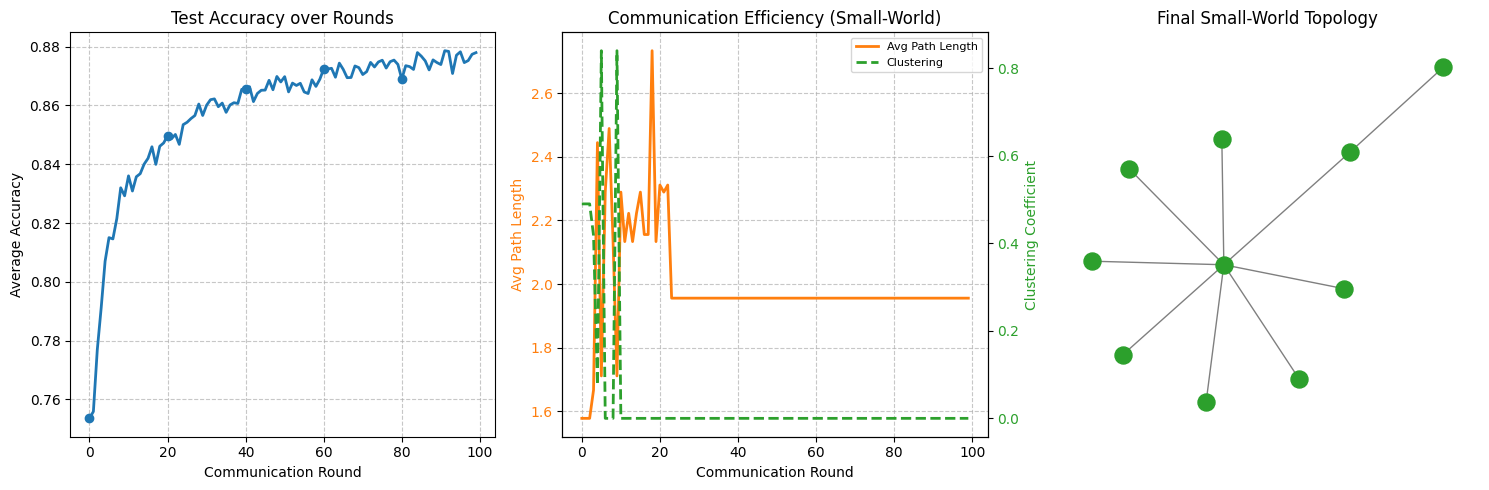

In [ ]:
training_history, final_network_graph = execute_decentralized_training()

figure_object = plotting_module.figure(figsize=(15, 5))
grid_specification = grid_specification_module.GridSpec(1, 3)

accuracy_axis = plotting_module.subplot(grid_specification[0])
accuracy_axis.plot(training_history['accuracy'], lw=2, color='#1f77b4', marker='o', markevery=max(1, len(training_history['accuracy']) // 5))
accuracy_axis.set_title("Test Accuracy over Rounds")
accuracy_axis.set_xlabel("Communication Round")
accuracy_axis.set_ylabel("Average Accuracy")
accuracy_axis.grid(True, linestyle='--', alpha=0.7)

efficiency_axis = plotting_module.subplot(grid_specification[1])
efficiency_axis.plot(training_history['avg_path_length'], lw=2, color='#ff7f0e', label='Avg Path Length')
efficiency_axis.set_xlabel("Communication Round")
efficiency_axis.set_ylabel("Avg Path Length", color='#ff7f0e')
efficiency_axis.tick_params(axis='y', labelcolor='#ff7f0e')
efficiency_axis_twin = efficiency_axis.twinx()
efficiency_axis_twin.plot(training_history['clustering'], lw=2, color='#2ca02c', linestyle='--', label='Clustering')
efficiency_axis_twin.set_ylabel("Clustering Coefficient", color='#2ca02c')
efficiency_axis_twin.tick_params(axis='y', labelcolor='#2ca02c')
efficiency_axis.set_title("Communication Efficiency (Small-World)")
efficiency_axis.grid(True, linestyle='--', alpha=0.7)
lines_a, labels_a = efficiency_axis.get_legend_handles_labels()
lines_b, labels_b = efficiency_axis_twin.get_legend_handles_labels()
efficiency_axis.legend(lines_a + lines_b, labels_a + labels_b, fontsize=8)

topology_axis = plotting_module.subplot(grid_specification[2])
node_positions = graph_library.spring_layout(final_network_graph, seed=42)
graph_library.draw_networkx_nodes(final_network_graph, node_positions, node_size=150, node_color='#2ca02c', ax=topology_axis)
graph_library.draw_networkx_edges(final_network_graph, node_positions, alpha=0.5, ax=topology_axis)
topology_axis.set_title("Final Small-World Topology")
topology_axis.axis('off')

plotting_module.tight_layout()
plotting_module.show()